# Mean-Only Training Diagnostics

This notebook performs a full diagnostic pass for runs created with `--training-stage mean_only`.

It will:
- Load a mean-only run from `anp_training_runs/mean_*`.
- Validate expected artifacts (`metrics.json`, `args.json`, optional `mean_model.pt`).
- Summarize train/val/test RMSE in original units.
- Break down performance by target channel and by snapshot.
- Quantify generalization gaps to assess overfitting risk.
- Build a compact scorecard for quick reporting.

In [1]:
from pathlib import Path
import json
import math
from typing import Any, Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

print('imports_ok')

imports_ok


In [3]:
# Config
OUTPUT_ROOT = Path('./anp_training_runs')
RUN_DIR: Optional[Path] = None

# If RUN_DIR is None, notebook will auto-pick latest mean_only run with metrics.json.
# Example manual override:
RUN_DIR = Path('./anp_training_runs/mean_all_profiles_20260323_115126')

In [4]:
def _safe_read_json(path: Path) -> Dict[str, Any]:
    if not path.exists():
        raise FileNotFoundError(f'Missing required file: {path}')
    with path.open('r', encoding='utf-8') as f:
        return json.load(f)


def find_mean_runs(output_root: Path) -> List[Path]:
    if not output_root.exists():
        return []
    runs = [p for p in output_root.glob('mean_*') if p.is_dir()]
    runs = [p for p in runs if (p / 'metrics.json').exists()]
    runs.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return runs


def select_run(output_root: Path, run_dir: Optional[Path]) -> Path:
    if run_dir is not None:
        if not run_dir.exists():
            raise FileNotFoundError(f'RUN_DIR does not exist: {run_dir}')
        return run_dir

    candidates = find_mean_runs(output_root)
    if not candidates:
        raise RuntimeError(f'No mean runs found in {output_root}. Run training with --training-stage mean_only first.')
    return candidates[0]


def load_run_artifacts(run_dir: Path) -> Dict[str, Any]:
    metrics = _safe_read_json(run_dir / 'metrics.json')
    args = _safe_read_json(run_dir / 'args.json') if (run_dir / 'args.json').exists() else {}

    payload = {
        'run_dir': run_dir,
        'metrics': metrics,
        'args': args,
    }

    # Validate stage
    stage = metrics.get('training_stage', '')
    if stage and stage != 'mean_only':
        print(f'Warning: metrics training_stage={stage} (expected mean_only)')

    # Checkpoint path can be absolute or relative to run dir depending on how it was written.
    ckpt_path = None
    mean_prior = metrics.get('mean_prior', {})
    ckpt_from_metrics = mean_prior.get('checkpoint')
    if isinstance(ckpt_from_metrics, str) and ckpt_from_metrics:
        c = Path(ckpt_from_metrics)
        if not c.exists():
            c2 = run_dir / c.name
            ckpt_path = c2 if c2.exists() else None
        else:
            ckpt_path = c
    elif (run_dir / 'mean_model.pt').exists():
        ckpt_path = run_dir / 'mean_model.pt'

    payload['mean_checkpoint_path'] = ckpt_path
    return payload

In [5]:
run_dir = select_run(OUTPUT_ROOT, RUN_DIR)
art = load_run_artifacts(run_dir)
metrics = art['metrics']
args = art['args']

print('Selected run:', run_dir)
print('target_name:', metrics.get('target_name'))
print('training_stage:', metrics.get('training_stage'))
print('mean checkpoint:', art.get('mean_checkpoint_path'))
print('n_train/n_val/n_test:', metrics.get('n_train'), metrics.get('n_val'), metrics.get('n_test'))

mean_metrics = metrics.get('mean_metrics', {})
if not mean_metrics:
    raise RuntimeError('No mean_metrics found in metrics.json. Ensure you trained with the updated mean_only workflow.')

print('mean_metrics keys:', list(mean_metrics.keys()))

Selected run: anp_training_runs/mean_all_profiles_20260323_115126
target_name: all_profiles
training_stage: mean_only
mean checkpoint: /mnt/home/mlee1/ANP_tests/anp_training_runs/mean_all_profiles_20260323_115126/mean_model.pt
n_train/n_val/n_test: 816 102 103
mean_metrics keys: ['train', 'val', 'test']


In [6]:
# High-level split summary
splits = ['train', 'val', 'test']
rows = []
for s in splits:
    m = mean_metrics.get(s, {})
    rows.append({
        'split': s,
        'n_tasks': m.get('n_tasks', np.nan),
        'rmse_original_units': m.get('rmse_original_units', np.nan),
        'rmse_core_original_units': m.get('rmse_core_original_units', np.nan),
        'rmse_outer_original_units': m.get('rmse_outer_original_units', np.nan),
    })

split_df = pd.DataFrame(rows)
split_df

,split,n_tasks,rmse_original_units,rmse_core_original_units,rmse_outer_original_units
0,train,3193,8.179961e+06,1.828644e+07,203039.414783
1,val,402,8.849039e+06,1.978224e+07,218290.427316
2,test,403,6.569776e+06,1.468680e+07,164022.918846


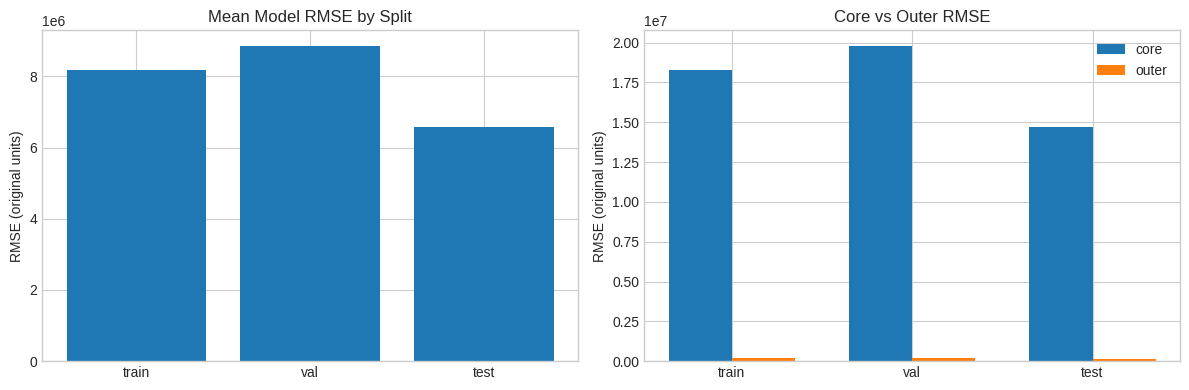

In [7]:
# Plot split-level diagnostics
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(split_df['split'], split_df['rmse_original_units'])
axes[0].set_title('Mean Model RMSE by Split')
axes[0].set_ylabel('RMSE (original units)')

x = np.arange(len(split_df))
w = 0.35
axes[1].bar(x - w / 2, split_df['rmse_core_original_units'], width=w, label='core')
axes[1].bar(x + w / 2, split_df['rmse_outer_original_units'], width=w, label='outer')
axes[1].set_xticks(x)
axes[1].set_xticklabels(split_df['split'])
axes[1].set_title('Core vs Outer RMSE')
axes[1].set_ylabel('RMSE (original units)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
# Per-target diagnostics
target_rows = []
for s in splits:
    per_target = mean_metrics.get(s, {}).get('per_target', {})
    for tname, vals in per_target.items():
        target_rows.append({
            'split': s,
            'target': tname,
            'rmse': vals.get('rmse_original_units', np.nan),
            'rmse_core': vals.get('rmse_core_original_units', np.nan),
            'rmse_outer': vals.get('rmse_outer_original_units', np.nan),
        })

target_df = pd.DataFrame(target_rows)
if target_df.empty:
    print('No per-target metrics available (single target run may still show one row depending on training output).')
else:
    display(target_df.sort_values(['target', 'split']).reset_index(drop=True))

    piv = target_df.pivot(index='target', columns='split', values='rmse')
    display(piv.sort_values('test', ascending=False) if 'test' in piv.columns else piv)

,split,target,rmse,rmse_core,rmse_outer
0,test,DM_density,2.009001e+06,4.474596e+06,1.990054e+05
1,train,DM_density,1.990500e+06,4.432756e+06,2.006939e+05
2,val,DM_density,1.857179e+06,4.133455e+06,2.000795e+05
3,test,gas_density,0.000000e+00,0.000000e+00,0.000000e+00
4,train,gas_density,0.000000e+00,0.000000e+00,0.000000e+00
5,val,gas_density,0.000000e+00,0.000000e+00,0.000000e+00
6,test,metallicity,2.791715e-01,4.963630e-01,1.892799e-01
7,train,metallicity,3.135338e-01,5.559008e-01,2.135952e-01
8,val,metallicity,3.107982e-01,5.358954e-01,2.212429e-01
9,test,potential,1.315331e+04,9.070501e+02,1.469885e+04


split,test,train,val
target,,,
stellar_density,1.726550e+07,2.155041e+07,2.333858e+07
DM_density,2.009001e+06,1.990500e+06,1.857179e+06
potential,1.315331e+04,1.272270e+04,1.218494e+04
temperature,3.557370e-01,3.523471e-01,3.443766e-01
metallicity,2.791715e-01,3.135338e-01,3.107982e-01
pressure,1.673780e-22,2.526110e-22,1.447183e-22
gas_density,0.000000e+00,0.000000e+00,0.000000e+00


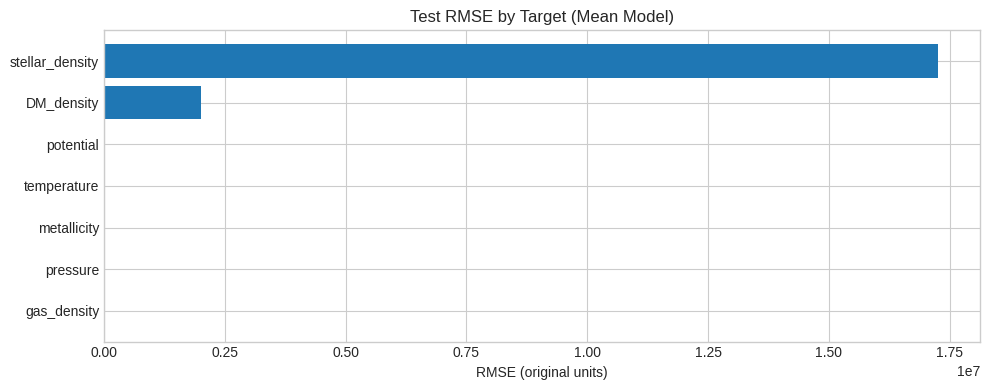

In [9]:
# Per-target plot (test split focus)
if not target_df.empty:
    test_df = target_df[target_df['split'] == 'test'].sort_values('rmse', ascending=False)

    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(test_df))))
    ax.barh(test_df['target'], test_df['rmse'])
    ax.invert_yaxis()
    ax.set_xlabel('RMSE (original units)')
    ax.set_title('Test RMSE by Target (Mean Model)')
    plt.tight_layout()
    plt.show()

,split,snapnum,rmse,n_points
0,test,44,3.025870e+06,132420
1,test,60,8.234899e+06,258810
2,test,74,1.340340e+07,303480
3,test,90,2.726039e+07,309780
4,train,44,3.047877e+06,1039710
5,train,60,7.907941e+06,2069670
6,train,74,1.908657e+07,2472630
7,train,90,3.306483e+07,2519850
8,val,44,2.535905e+06,115410
9,val,60,8.277734e+06,250620


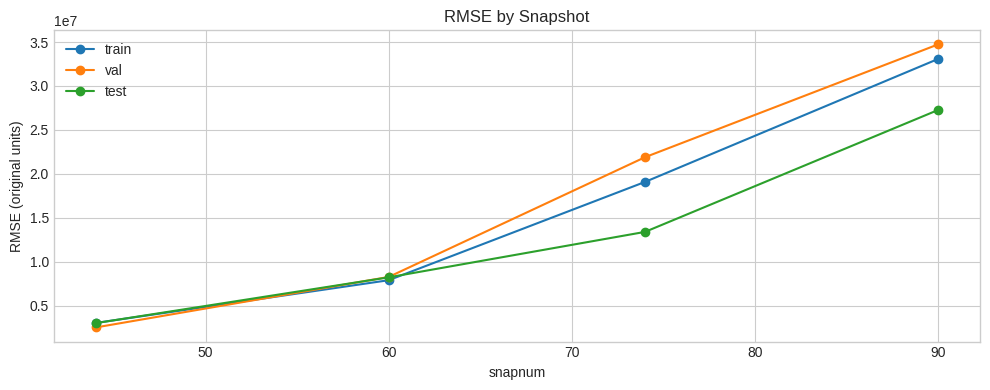

In [10]:
# Per-snapshot diagnostics
snap_rows = []
for s in splits:
    per_snap = mean_metrics.get(s, {}).get('per_snapshot', {})
    for snap, vals in per_snap.items():
        snap_rows.append({
            'split': s,
            'snapnum': int(snap),
            'rmse': vals.get('rmse_original_units', np.nan),
            'n_points': vals.get('n_points', np.nan),
        })

snap_df = pd.DataFrame(snap_rows)
if snap_df.empty:
    print('No per-snapshot metrics available.')
else:
    display(snap_df.sort_values(['split', 'snapnum']).reset_index(drop=True))

    fig, ax = plt.subplots(figsize=(10, 4))
    for s in splits:
        d = snap_df[snap_df['split'] == s].sort_values('snapnum')
        if len(d) > 0:
            ax.plot(d['snapnum'], d['rmse'], marker='o', label=s)
    ax.set_title('RMSE by Snapshot')
    ax.set_xlabel('snapnum')
    ax.set_ylabel('RMSE (original units)')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [11]:
# Generalization and overfit indicators
def _get_split_rmse(name: str) -> float:
    return float(mean_metrics.get(name, {}).get('rmse_original_units', np.nan))

rmse_train = _get_split_rmse('train')
rmse_val = _get_split_rmse('val')
rmse_test = _get_split_rmse('test')

eps = 1e-12
gap_val = rmse_val - rmse_train
gap_test = rmse_test - rmse_train
ratio_val = rmse_val / max(eps, rmse_train)
ratio_test = rmse_test / max(eps, rmse_train)

scorecard = pd.DataFrame([
    {'metric': 'train_rmse', 'value': rmse_train},
    {'metric': 'val_rmse', 'value': rmse_val},
    {'metric': 'test_rmse', 'value': rmse_test},
    {'metric': 'val_minus_train', 'value': gap_val},
    {'metric': 'test_minus_train', 'value': gap_test},
    {'metric': 'val_to_train_ratio', 'value': ratio_val},
    {'metric': 'test_to_train_ratio', 'value': ratio_test},
])

display(scorecard)

def overfit_flag(val_ratio: float, test_ratio: float) -> str:
    # Heuristic thresholds for quick triage.
    worst = max(val_ratio, test_ratio)
    if not np.isfinite(worst):
        return 'unknown'
    if worst <= 1.10:
        return 'low_risk'
    if worst <= 1.25:
        return 'moderate_risk'
    return 'high_risk'

print('overfit_risk_flag:', overfit_flag(ratio_val, ratio_test))

,metric,value
0,train_rmse,8.179961e+06
1,val_rmse,8.849039e+06
2,test_rmse,6.569776e+06
3,val_minus_train,6.690777e+05
4,test_minus_train,-1.610185e+06
5,val_to_train_ratio,1.081795e+00
6,test_to_train_ratio,8.031549e-01


overfit_risk_flag: low_risk


In [12]:
# Optional: inspect mean checkpoint metadata (if available)
ckpt_path = art.get('mean_checkpoint_path')
if ckpt_path is None:
    print('No mean checkpoint found to inspect.')
else:
    import torch

    payload = torch.load(ckpt_path, map_location='cpu')
    model_cfg = payload.get('mean_model_config', {})
    print('checkpoint:', ckpt_path)
    print('target_name:', payload.get('target_name'))
    print('target_names:', payload.get('target_names'))
    print('mean_model_config:', model_cfg)

    mm = payload.get('mean_metrics')
    if isinstance(mm, dict):
        print('checkpoint includes mean_metrics:', list(mm.keys()))

checkpoint: /mnt/home/mlee1/ANP_tests/anp_training_runs/mean_all_profiles_20260323_115126/mean_model.pt
target_name: all_profiles
target_names: ['potential', 'DM_density', 'stellar_density', 'gas_density', 'temperature', 'pressure', 'metallicity']
mean_model_config: {'y_dim': 7, 'hidden_dim': 128, 'use_redshift': True, 'theta_dim': 0, 'theta_start_idx': 2, 'n_hidden_layers': 2}
checkpoint includes mean_metrics: ['train', 'val', 'test']


/tmp/ipykernel_505620/679105792.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  payload = torch.load(ckpt_path, map_location='cpu')


## Profile Generation And True-Profile Comparison

This section regenerates mean-model profiles on real data and compares them directly to the true profiles.

It includes:
- split-aware sampling from the same dataset construction as training,
- profile overlays (true vs mean-predicted),
- residual curves,
- per-target RMSE summaries for sampled profile tasks.

In [17]:
import argparse

import torch

import train_anp_emulator as tae


def _namespace_from_args_dict(args_dict: Dict[str, Any]) -> argparse.Namespace:
    ns = argparse.Namespace(**args_dict)

    # Reconstruct derived fields expected by build/eval helpers.
    if not hasattr(ns, 'resolved_all_profile_targets'):
        if getattr(ns, 'target_name', None) == 'all_profiles':
            subset = getattr(ns, 'all_profiles_subset', None)
            if subset:
                selected = set(subset)
                ns.resolved_all_profile_targets = [name for name in tae.ALL_PROFILE_TARGETS if name in selected]
            else:
                ns.resolved_all_profile_targets = list(tae.ALL_PROFILE_TARGETS)
        else:
            ns.resolved_all_profile_targets = [getattr(ns, 'target_name')]

    snaps = getattr(ns, 'resolved_snapnums', None)
    if snaps is None:
        snaps = getattr(ns, 'snapnums', None)
    if snaps:
        ns.resolved_snapnums = [int(s) for s in snaps]
    else:
        ns.resolved_snapnums = [int(getattr(ns, 'snapnum'))]

    redshift_map = getattr(ns, 'redshift_by_snap', None)
    if redshift_map is None:
        redshift_map = tae.parse_snapshot_redshifts(getattr(ns, 'snapshot_redshifts'))
    # args.json stores dict keys as strings; build_tasks expects integer snap keys.
    ns.redshift_by_snap = {int(k): float(v) for k, v in dict(redshift_map).items()}

    if not hasattr(ns, 'use_continuous_redshift_feature'):
        ns.use_continuous_redshift_feature = bool(not getattr(ns, 'disable_continuous_redshift_feature', False))

    # Mean-model architecture helpers from training.
    if not hasattr(ns, 'mean_theta_dim'):
        ns.mean_theta_dim = int(getattr(ns, 'theta_dim', 0)) if bool(getattr(ns, 'mean_use_theta', False)) else 0
    if not hasattr(ns, 'mean_n_hidden'):
        ns.mean_n_hidden = 3 if int(ns.mean_theta_dim) > 0 else 2

    return ns


def _load_mean_model_for_profiles(ckpt_path: Path):
    if ckpt_path is None or not Path(ckpt_path).exists():
        raise FileNotFoundError('Mean checkpoint is required for profile generation diagnostics.')

    mean_model, payload = tae.load_mean_checkpoint(Path(ckpt_path), device=torch.device('cpu'))
    mean_model.eval()
    return mean_model, payload


def _predict_mean_for_task(task, mean_model, batch_size: int = 262144) -> np.ndarray:
    ts = int(mean_model.theta_start_idx)
    td = int(mean_model.theta_dim)

    flat_x = torch.from_numpy(task.x[:, :, :2].reshape(-1, 2)).float()
    theta_flat = None
    if td > 0:
        theta_flat = torch.from_numpy(task.x[:, :, ts:ts + td].reshape(-1, td)).float()
    z_col = torch.full((flat_x.shape[0],), float(task.redshift), dtype=torch.float32) if mean_model.use_redshift else None

    preds = []
    for i in range(0, flat_x.shape[0], max(1, int(batch_size))):
        xb = flat_x[i:i + batch_size]
        tb = theta_flat[i:i + batch_size] if theta_flat is not None else None
        zb = z_col[i:i + batch_size] if z_col is not None else None
        with torch.no_grad():
            pb = mean_model(xb[:, 0], xb[:, 1], theta=tb, redshift=zb)
        preds.append(pb.cpu())

    return torch.cat(preds, dim=0).numpy().reshape(task.y.shape).astype(np.float32)


run_args = _namespace_from_args_dict(args)
mean_model, mean_payload = _load_mean_model_for_profiles(art.get('mean_checkpoint_path'))

all_families = tae.build_tasks(run_args)
train_raw, val_raw, test_raw = tae.split_tasks(
    all_families,
    train_frac=float(getattr(run_args, 'train_frac', 0.8)),
    val_frac=float(getattr(run_args, 'val_frac', 0.1)),
    seed=int(getattr(run_args, 'seed', 42)),
)

print('dataset rebuilt for profile diagnostics')
print('families total/train/val/test:', len(all_families), len(train_raw), len(val_raw), len(test_raw))
print('mean model config:', mean_payload.get('mean_model_config', {}))

/mnt/home/mlee1/ANP_tests/train_anp_emulator.py:442: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  raw = torch.load(checkpoint_path, map_location=device)


Built 1021 run families (3998 snapshots) from 1024 discovered runs (skipped 3).
Example family run_id=0, snapshots=4, x=(150, 30, 38), y=(150, 30, 7)
dataset rebuilt for profile diagnostics
families total/train/val/test: 1021 816 102 103
mean model config: {'y_dim': 7, 'hidden_dim': 128, 'use_redshift': True, 'theta_dim': 0, 'theta_start_idx': 2, 'n_hidden_layers': 2}


In [18]:
# Configure profile comparison sampling.
COMPARE_SPLIT = 'test'   # one of: train, val, test
MAX_TASKS_TO_PLOT = 3    # number of run/snapshot tasks to visualize
MAX_HALOS_PER_TASK = 3   # halos per task
TARGET_LIMIT = 4         # max channels to plot for all_profiles runs
PRED_BATCH_SIZE = int(getattr(run_args, 'mean_predict_batch_size', 262144))

split_map = {
    'train': tae.flatten_family_tasks(train_raw),
    'val': tae.flatten_family_tasks(val_raw),
    'test': tae.flatten_family_tasks(test_raw),
}
if COMPARE_SPLIT not in split_map:
    raise ValueError(f'Invalid COMPARE_SPLIT={COMPARE_SPLIT}')

compare_tasks = split_map[COMPARE_SPLIT]
if len(compare_tasks) == 0:
    raise RuntimeError(f'No tasks available for split {COMPARE_SPLIT}')

rng = np.random.default_rng(123)
sel_task_idx = rng.choice(len(compare_tasks), size=min(MAX_TASKS_TO_PLOT, len(compare_tasks)), replace=False)
sel_tasks = [compare_tasks[i] for i in sel_task_idx]

if metrics.get('target_name') == 'all_profiles':
    target_names_plot = list(metrics.get('target_names', []))
    if len(target_names_plot) == 0:
        target_names_plot = [f'target_{i}' for i in range(sel_tasks[0].y.shape[-1])]
else:
    target_names_plot = [metrics.get('target_name', 'target')]

if TARGET_LIMIT > 0 and len(target_names_plot) > TARGET_LIMIT:
    target_names_plot = target_names_plot[:TARGET_LIMIT]

print('split:', COMPARE_SPLIT)
print('tasks selected:', len(sel_tasks), 'out of', len(compare_tasks))
print('targets plotted:', target_names_plot)

split: test
tasks selected: 3 out of 403
targets plotted: ['potential', 'DM_density', 'stellar_density', 'gas_density']


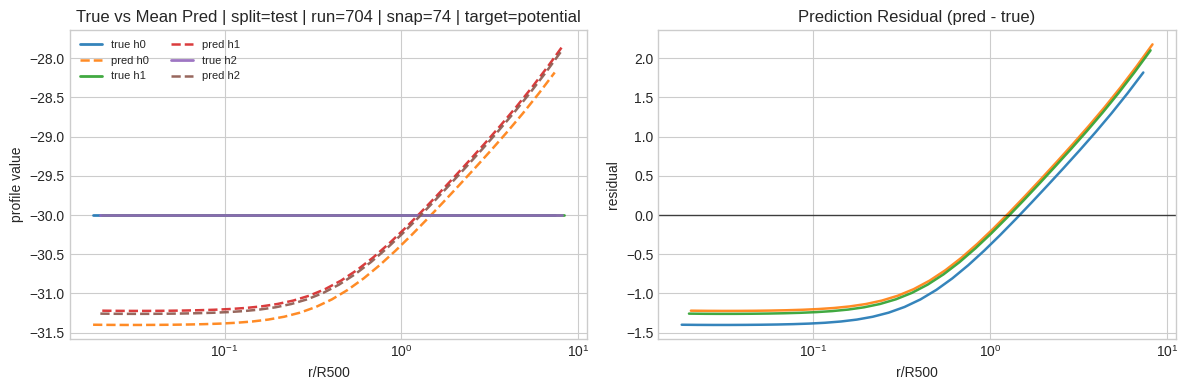

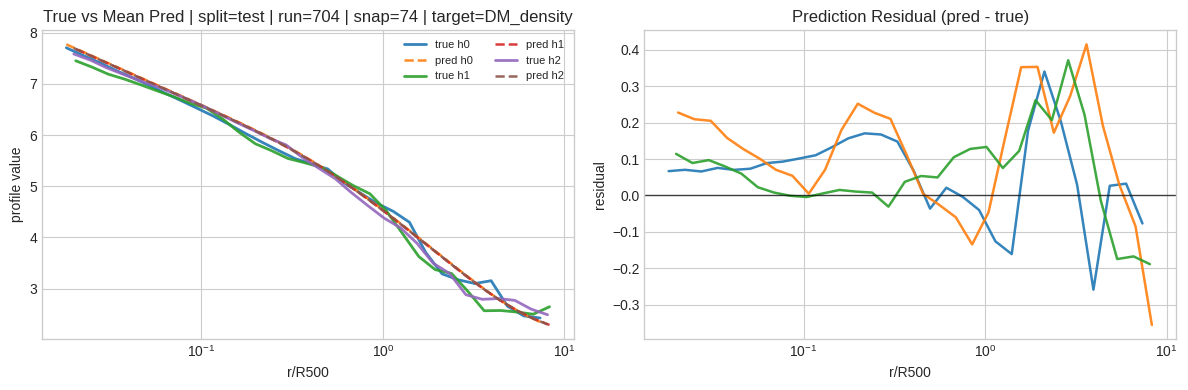

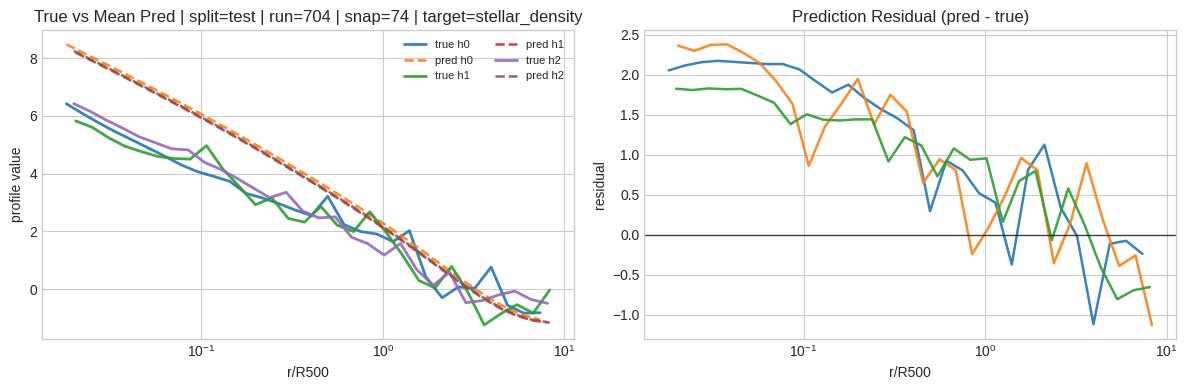

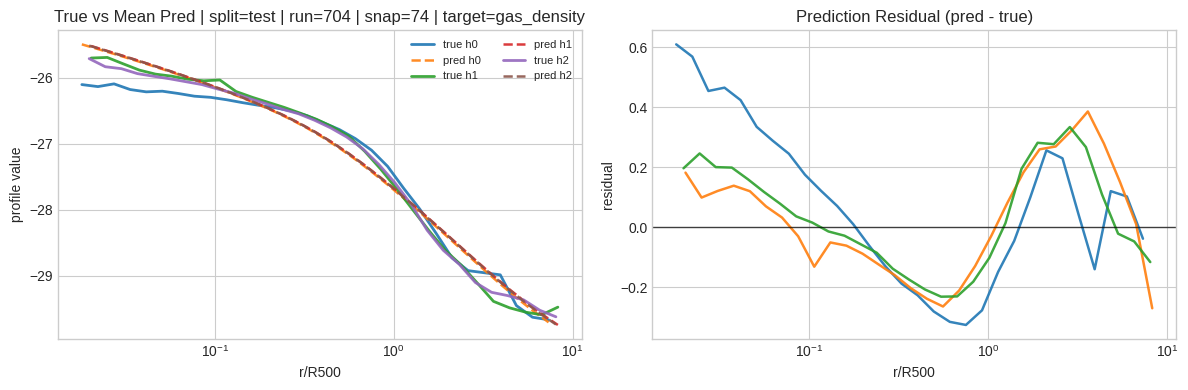

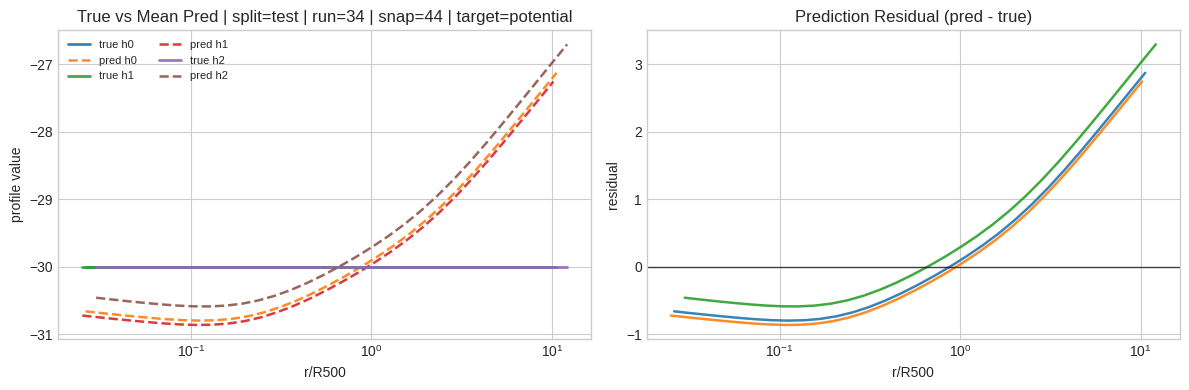

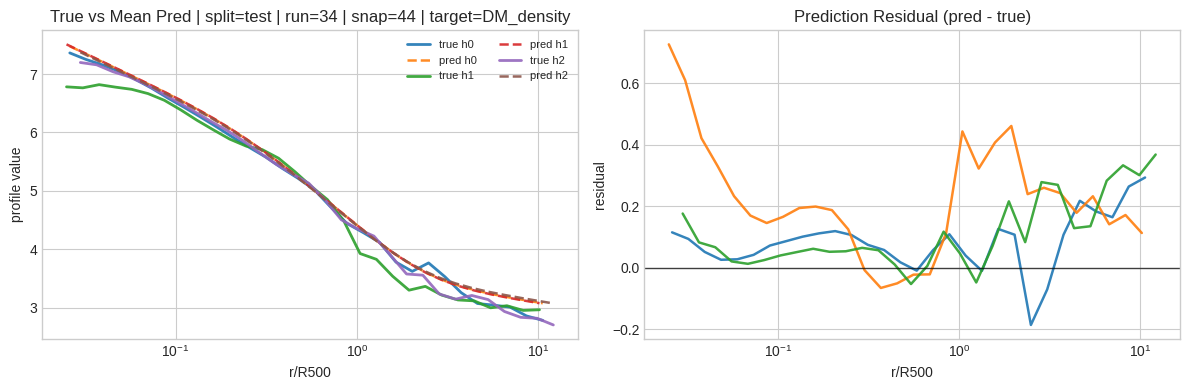

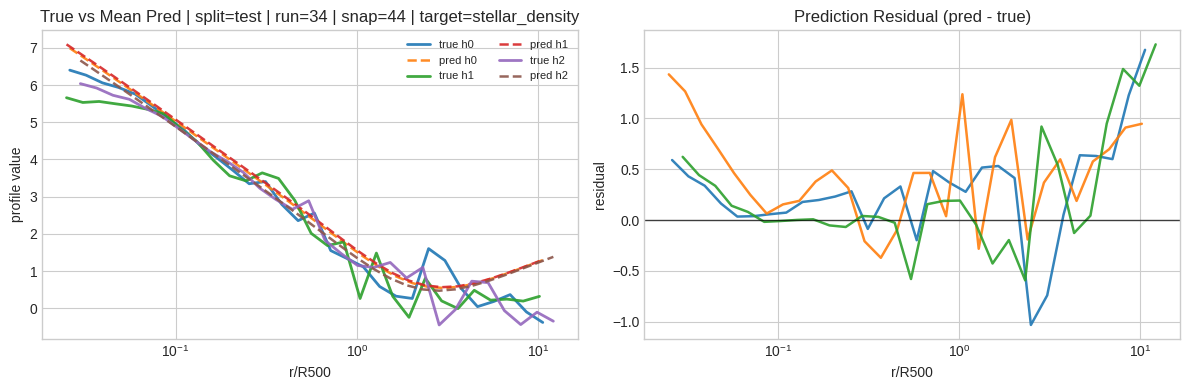

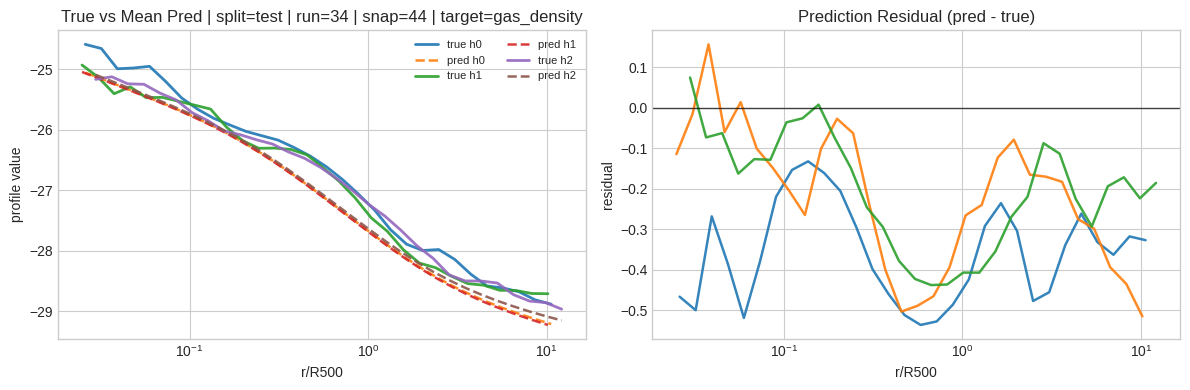

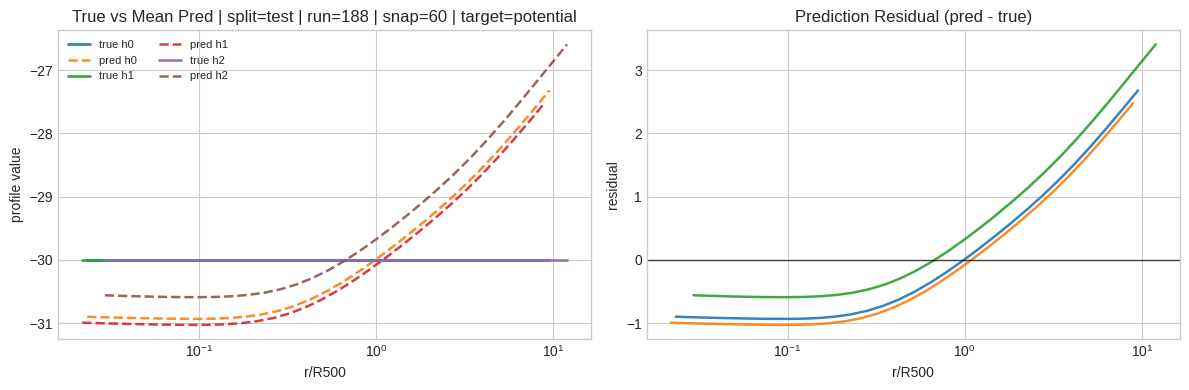

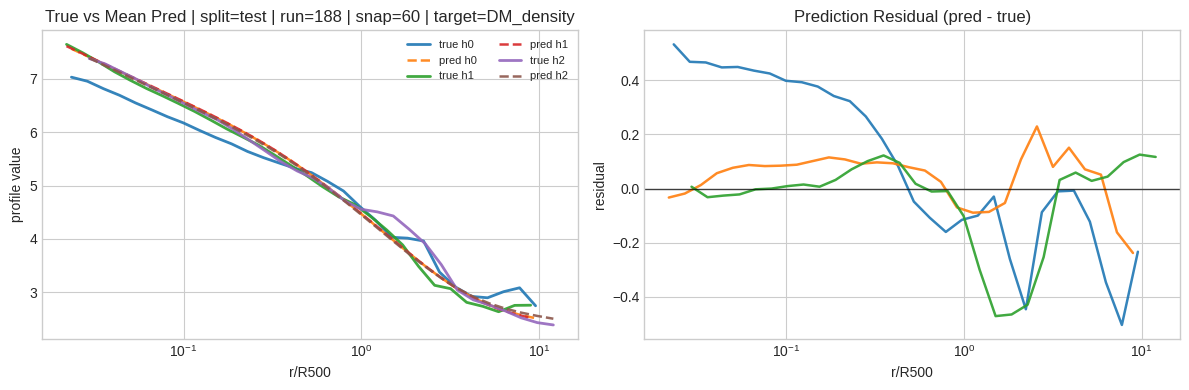

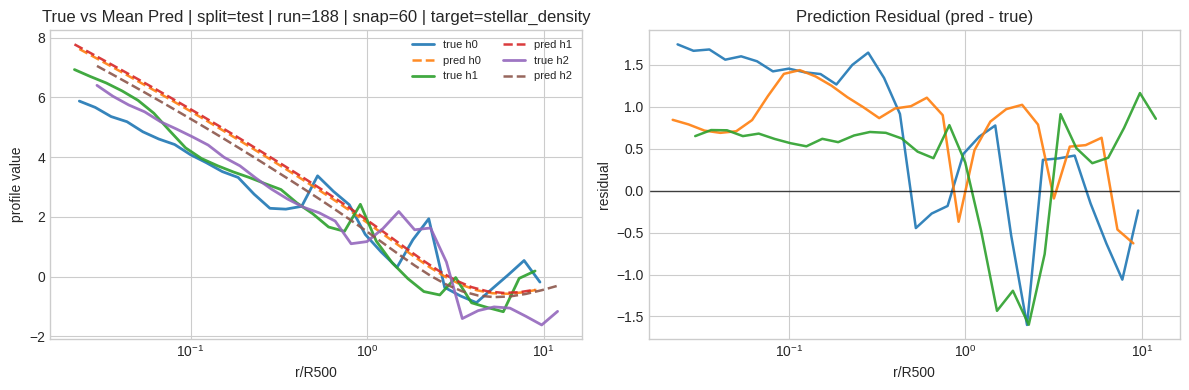

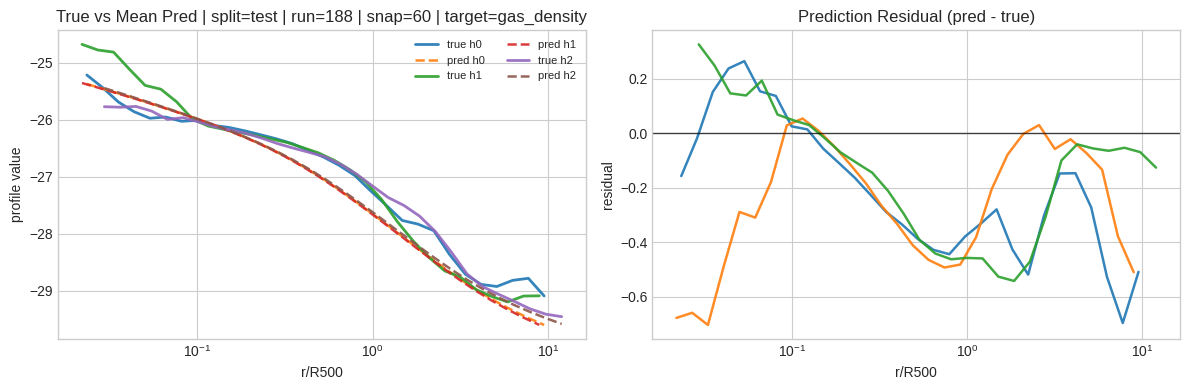

,split,run_id,snapnum,target,rmse,mae,n_halo,n_r
0,test,704,74,DM_density,0.235089,0.165688,150,30
1,test,34,44,DM_density,0.217710,0.166135,40,30
2,test,188,60,DM_density,0.159067,0.115114,117,30
3,test,704,74,gas_density,0.323379,0.260216,150,30
4,test,188,60,gas_density,0.257541,0.207895,117,30
5,test,34,44,gas_density,0.247019,0.193037,40,30
6,test,704,74,potential,8.121374,3.380462,150,30
7,test,188,60,potential,5.702873,2.334644,117,30
8,test,34,44,potential,2.409917,1.419072,40,30
9,test,188,60,stellar_density,5.670753,1.586291,117,30


,target,rmse_mean,rmse_std,mae_mean
0,potential,5.411388,2.866864,2.378059
1,stellar_density,3.697861,1.756571,1.117500
2,gas_density,0.275980,0.041385,0.220382
3,DM_density,0.203955,0.039834,0.148979


In [19]:
profile_rows = []

for it, task in enumerate(sel_tasks):
    y_true = task.y.astype(np.float32)
    y_pred = _predict_mean_for_task(task, mean_model=mean_model, batch_size=PRED_BATCH_SIZE)
    resid = y_pred - y_true

    # Use physical radius proxy from model input (x[...,1] = log10(r/R500)).
    logr = task.x[:, :, 1]
    radius_ratio = np.power(10.0, logr)

    n_halo = int(task.n_halo)
    halo_sel = np.arange(min(MAX_HALOS_PER_TASK, n_halo))

    for ch, tname in enumerate(target_names_plot):
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        for h in halo_sel:
            rr = radius_ratio[h]
            axes[0].plot(rr, y_true[h, :, ch], lw=2, alpha=0.9, label=f'true h{h}')
            axes[0].plot(rr, y_pred[h, :, ch], lw=1.8, ls='--', alpha=0.9, label=f'pred h{h}')

        axes[0].set_xscale('log')
        axes[0].set_title(
            f'True vs Mean Pred | split={COMPARE_SPLIT} | run={task.run_id} | snap={task.snapnum} | target={tname}'
        )
        axes[0].set_xlabel('r/R500')
        axes[0].set_ylabel('profile value')
        axes[0].legend(ncol=2, fontsize=8)

        for h in halo_sel:
            rr = radius_ratio[h]
            axes[1].plot(rr, resid[h, :, ch], lw=1.8, alpha=0.9, label=f'resid h{h}')
        axes[1].axhline(0.0, color='k', lw=1.0, alpha=0.7)
        axes[1].set_xscale('log')
        axes[1].set_title('Prediction Residual (pred - true)')
        axes[1].set_xlabel('r/R500')
        axes[1].set_ylabel('residual')

        plt.tight_layout()
        plt.show()

        rmse_ch = float(np.sqrt(np.mean((resid[:, :, ch]) ** 2)))
        mae_ch = float(np.mean(np.abs(resid[:, :, ch])))

        profile_rows.append({
            'split': COMPARE_SPLIT,
            'run_id': int(task.run_id),
            'snapnum': int(task.snapnum),
            'target': tname,
            'rmse': rmse_ch,
            'mae': mae_ch,
            'n_halo': int(task.n_halo),
            'n_r': int(task.n_r),
        })

profile_df = pd.DataFrame(profile_rows)
display(profile_df.sort_values(['target', 'rmse'], ascending=[True, False]).reset_index(drop=True))

if len(profile_df) > 0:
    summary = profile_df.groupby('target', as_index=False).agg(
        rmse_mean=('rmse', 'mean'),
        rmse_std=('rmse', 'std'),
        mae_mean=('mae', 'mean'),
    )
    display(summary.sort_values('rmse_mean', ascending=False).reset_index(drop=True))

## Interpretation Guide

Use this checklist to argue the mean model is strong before ANP residual training:

1. **Low absolute RMSE** on validation and test (split table + bar plot).
2. **Stable generalization** with $\text{val/train}$ and $\text{test/train}$ near 1.0.
3. **No catastrophic target outliers** in per-target test RMSE.
4. **No redshift collapse** in per-snapshot RMSE curves.
5. **Core behavior is acceptable** (core vs outer RMSE not wildly divergent).

If all five look good, the residual ANP stage is justified as a refinement step instead of a rescue step.